In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [ ]:
training_set = tf.keras.utils.image_dataset_from_directory(
    '/content/drive/MyDrive/fruit-veg-recognition/train',
    labels = "inferred",
    label_mode = "categorical",
    class_names= None,
    color_mode = "rgb",
    batch_size =32,
    image_size = (64,64),
    shuffle= True,
    seed = None,
    validation_split= None,
    subset = None,
    interpolation= "bilinear",
    follow_links= False,
    crop_to_aspect_ratio= False,
)





Found 3115 files belonging to 36 classes.


In [ ]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    '/content/drive/MyDrive/fruit-veg-recognition/validation',
     labels = "inferred",
    label_mode = "categorical",
    class_names= None,
    color_mode = "rgb",
    batch_size =32,
    image_size = (64,64),
    shuffle= True,
    seed = None,
    validation_split= None,
    subset = None,
    interpolation= "bilinear",
    follow_links= False,
    crop_to_aspect_ratio= False,

)


Found 351 files belonging to 36 classes.


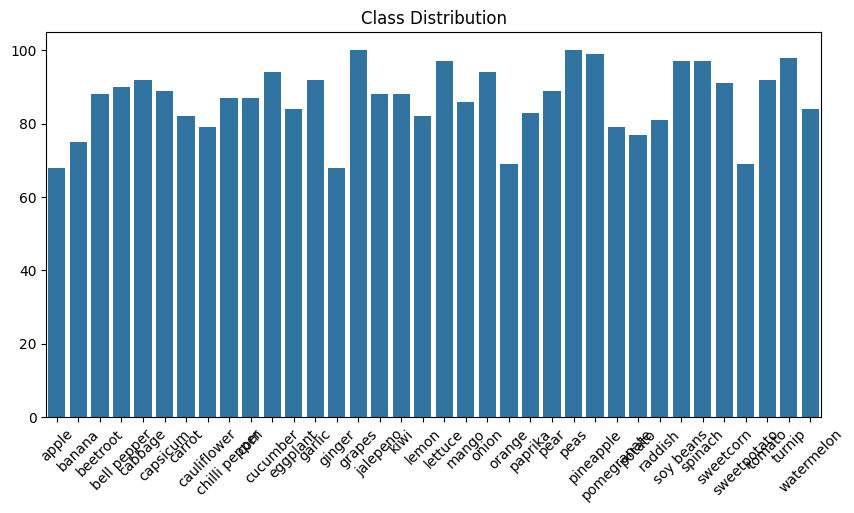

In [ ]:
#Class Distribution Visualization
import seaborn as sns
class_names = training_set.class_names
class_counts = {name: 0 for name in class_names}
for images, labels in training_set:
    for label in labels.numpy():
        class_counts[class_names[np.argmax(label)]] += 1

plt.figure(figsize=(10, 5))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()


MODEL BUILDING

In [ ]:
cnn = tf.keras.models.Sequential()


In [ ]:
cnn.add(tf.keras.layers.Conv2D(filters= 64,kernel_size=3,activation='relu',input_shape=[64, 64, 3]))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn.add(tf.keras.layers.Conv2D(filters= 64,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [ ]:
cnn.add(tf.keras.layers.Dropout(0.5))      ##overfitting-reason

In [ ]:
cnn.add(tf.keras.layers.Flatten())

In [ ]:
cnn.add(tf.keras.layers.Dense(units=128,activation='relu'))

In [ ]:
cnn.add(tf.keras.layers.Dense(units=36,activation='softmax'))   ##outputLayerBUild

Compilation And Training

In [ ]:
cnn.compile(optimizer='rmsprop',loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
training_history=cnn.fit(x=training_set,validation_data=validation_set,epochs=30)

Epoch 1/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 186s 2s/step - accuracy: 0.0426 - loss: 22.7653 - val_accuracy: 0.1026 - val_loss: 3.5132
Epoch 2/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.0691 - loss: 4.0951 - val_accuracy: 0.2222 - val_loss: 3.1759
Epoch 3/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.1238 - loss: 3.8818 - val_accuracy: 0.3191 - val_loss: 2.8490
Epoch 4/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.1743 - loss: 4.2310 - val_accuracy: 0.4274 - val_loss: 2.4149
Epoch 5/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.2270 - loss: 3.2136 - val_accuracy: 0.5014 - val_loss: 2.1720
Epoch 6/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.2968 - loss: 2.8210 - val_accuracy: 0.4131 - val_loss: 2.7598
Epoch 7/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.3643 - loss: 2.6127 - val_accuracy: 0.4672 - val_loss: 2.8242
Epoch 8/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.4262 - loss: 3.2321 - val_accuracy: 0.4729 - 

Save Model


In [ ]:
cnn.save('trained_model.h5')

In [ ]:
training_history.history      ### dictonaries of his will be returend

{'accuracy': [0.04012840986251831,
  0.07415730506181717,
  0.12231139838695526,
  0.1852327436208725,
  0.23499196767807007,
  0.32070624828338623,
  0.3874799311161041,
  0.4523274600505829,
  0.510754406452179,
  0.5556982159614563,
  0.5961476564407349,
  0.6356340050697327,
  0.6548956632614136,
  0.6699839234352112,
  0.708507239818573,
  0.7319422364234924,
  0.7415730357170105,
  0.7717496156692505,
  0.7929373979568481,
  0.8051364421844482,
  0.8086677193641663,
  0.8304975628852844,
  0.843338668346405,
  0.8391653299331665,
  0.8542535901069641,
  0.8645265102386475,
  0.866131603717804,
  0.8696629405021667,
  0.874799370765686,
  0.8869984149932861],
 'loss': [8.338616371154785,
  4.033865928649902,
  3.92374587059021,
  3.74198055267334,
  3.2889859676361084,
  2.794154405593872,
  2.5590932369232178,
  2.527533531188965,
  2.1656694412231445,
  2.002769708633423,
  1.6414601802825928,
  1.5956389904022217,
  1.56527841091156,
  1.6803715229034424,
  1.4759564399719238,


In [ ]:
import json
with open('training_hist.json','w') as f:
 json.dump(training_history.history,f)

In [ ]:
print(training_history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


Model Accuracy

In [ ]:
print("validation set accuracy:{}" .format(training_history.history['val_accuracy'][-1]*100))

validation set accuracy:91.45299196243286


Visualization of training

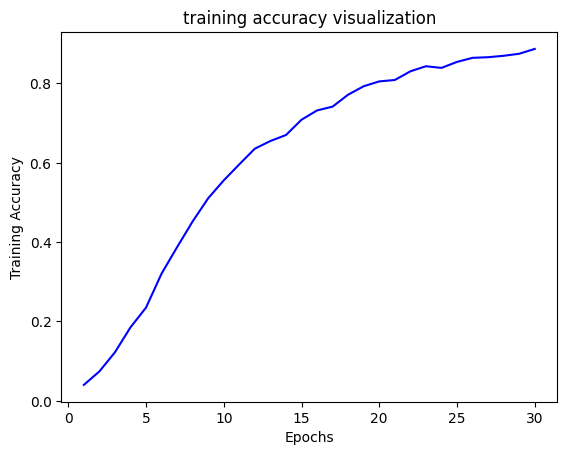

In [ ]:
epochs=[i for i in range(1,31)]
plt.plot(epochs,training_history.history['accuracy'],color='blue')
plt.xlabel('Epochs')
plt.ylabel('Training Accuracy')
plt.title('training accuracy visualization')
plt.show()

accuracy of validation

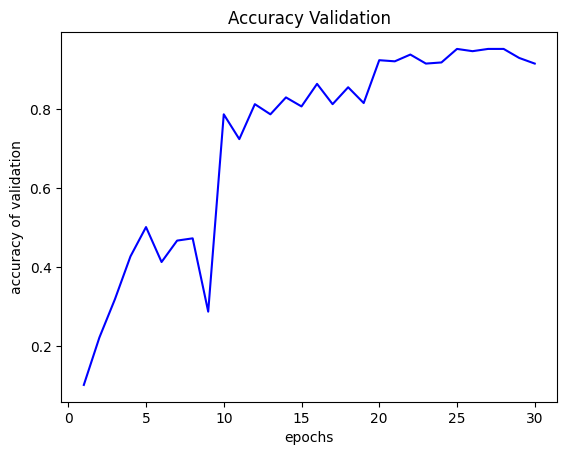

In [ ]:
plt.plot(epochs,training_history.history[ 'val_accuracy'],color='blue')
plt.xlabel('epochs')
plt.ylabel('accuracy of validation')
plt.title('Accuracy Validation')
plt.show()